## W25-3248: Stress Testing using SFNO model

- Earth2-focused project in conjunction with RML 
- Examine extreme rainfall event(s) that impacted Dublin, Ireland in summer 2007 
- The high-level aim is to set up AI-based weather forecasts to develop counterfactual analyses (i.e. are there plausible scenarios that could have made a historical flooding event even worse)

In [1]:
import numpy as np
import xarray as xr 
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

### Read in relevant precip data 

- Observations
    - E-OBS gridded daily precipitation dataset (Copernicus)
    - GPM-IMERG satellite-based daily precipitation dataset (NASA)
    - Met Eireann station observations (6 stations within Dublin) 
- Forecast data 
    - TIGGE archive (ECMWF and UKMO ensemble forecasts)
    - 50 ensemble members run twice daily (00 and 12Z) out to T+168 (7 days)
- Processing 
    - Create a time-series to determine which dates stand out 
    - Subset to the UK and Ireland 

In [41]:
data_path = '/mnt/metdata/W25-3248/'
eobs_precip = xr.open_dataset(f'{data_path}/rr_ens_mean_0.1deg_reg_1995-2010_v30.0e.nc')
eobs_precip = eobs_precip.sel(time=slice('2007-06-01','2007-08-31'),
                              latitude=slice(52.0, 55.0),
                              longitude=slice(-8.0, -5.0))

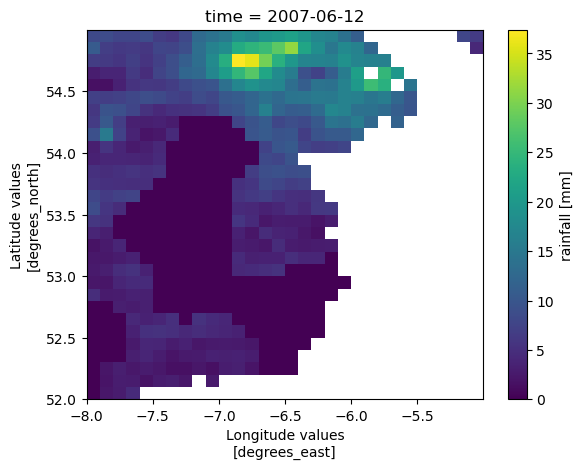

In [42]:
dublin_eobs_daily = eobs_precip['rr'].mean(dim=('latitude','longitude'))
dublin_eobs_daily.quantile(0.95)
eobs_precip['rr'].sel(time='2007-06-12').plot()